<a href="https://colab.research.google.com/github/chen323-ux/CTP/blob/main/PCR_data_processor_shared_housekeeping_by_group.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# ============================================================
# Build the plate layout
# ============================================================

# Plate rows
plate_rows = list("ABCDEFGH")

# Ask for one group name per plate row
# Example:
# Cerebellum,Midbrain,Hippocampus,Cortex,PFC,,,
group_input = input(
    "Enter group names for rows A-H, separated by commas. "
    "Use blanks for empty rows:\n"
)

groups = [g.strip() for g in group_input.split(",")]

# Make sure there are exactly 8 row entries
if len(groups) < 8:
    groups += [""] * (8 - len(groups))
elif len(groups) > 8:
    groups = groups[:8]


# Each block contains one technical triplicate
triplicate_column_blocks = [
    ("1-3", range(1, 4)),
    ("4-6", range(4, 7)),
    ("7-9", range(7, 10)),
    ("10-12", range(10, 13))
]


records = []

# Ask for the four primer assignments separately for every nonempty row
for row_letter, group in zip(plate_rows, groups):

    if group == "":
        continue

    while True:

        primer_input = input(
            f"\nRow {row_letter} ({group})\n"
            "Enter the primer names for triplicate blocks "
            "1-3, 4-6, 7-9, and 10-12, separated by commas.\n"
            "Use a blank entry for an unused triplicate block:\n"
        )

        row_primers = [
            primer.strip()
            for primer in primer_input.split(",")
        ]

        if len(row_primers) == 4:
            break

        print(
            "Please enter exactly 4 comma-separated entries "
            "(one entry for each triplicate block)."
        )


    # Create one record for every used well in the current row
    for block_number, ((block_label, columns), primer) in enumerate(
        zip(triplicate_column_blocks, row_primers),
        start=1
    ):

        # Skip an unused triplicate block
        if primer == "":
            continue

        for replicate_number, column_number in enumerate(
            columns,
            start=1
        ):

            well = f"{row_letter}{column_number}"

            records.append({
                "Well": well,

                # Keep the physical plate row as a unique identifier
                "Plate Row": row_letter,

                # A unique display label, even when group names repeat
                "Row Sample": f"{row_letter} - {group}",

                # Keep the user-entered biological group name
                "Group": group,

                # Identify the exact technical-triplicate block
                "Block Number": block_number,
                "Triplicate Block": block_label,

                "Primer": primer,
                "Technical Replicate": replicate_number
            })


final_df = pd.DataFrame(records)

print("\nPlate layout created:")
display(final_df)

# Example group input:
# WT,KO,WT,KO
#18s,VCAN,LDLRAD2,FABP6
#MK167,LDHA,LGSF11,
# The program will then ask for four primer entries separately
# for row A, row B, row C, and so on.



Enter group names for rows A-H, separated by commas. Use blanks for empty rows:
WT,KO,WT,KO

Row A (WT)
Enter the primer names for triplicate blocks 1-3, 4-6, 7-9, and 10-12, separated by commas.
Use a blank entry for an unused triplicate block:
18s,VCAN,LDLRAD2,FABP6

Row B (KO)
Enter the primer names for triplicate blocks 1-3, 4-6, 7-9, and 10-12, separated by commas.
Use a blank entry for an unused triplicate block:
18s,VCAN,LDLRAD2,FABP6

Row C (WT)
Enter the primer names for triplicate blocks 1-3, 4-6, 7-9, and 10-12, separated by commas.
Use a blank entry for an unused triplicate block:
MK167,LDHA,LGSF11, 

Row D (KO)
Enter the primer names for triplicate blocks 1-3, 4-6, 7-9, and 10-12, separated by commas.
Use a blank entry for an unused triplicate block:
MK167,LDHA,LGSF11, 

Plate layout created:


,Well,Plate Row,Row Sample,Group,Block Number,Triplicate Block,Primer,Technical Replicate
0,A1,A,A - WT,WT,1,1-3,18s,1
1,A2,A,A - WT,WT,1,1-3,18s,2
2,A3,A,A - WT,WT,1,1-3,18s,3
3,A4,A,A - WT,WT,2,4-6,VCAN,1
4,A5,A,A - WT,WT,2,4-6,VCAN,2
5,A6,A,A - WT,WT,2,4-6,VCAN,3
6,A7,A,A - WT,WT,3,7-9,LDLRAD2,1
7,A8,A,A - WT,WT,3,7-9,LDLRAD2,2
8,A9,A,A - WT,WT,3,7-9,LDLRAD2,3
9,A10,A,A - WT,WT,4,10-12,FABP6,1


In [2]:

# =========================
# Upload/read qPCR result file
# =========================

from google.colab import files

uploaded = files.upload()
qpcr_file = list(uploaded.keys())[0]

# Read Excel or CSV
if qpcr_file.endswith(".xlsx") or qpcr_file.endswith(".xls"):
    qpcr_df = pd.read_excel(qpcr_file)
elif qpcr_file.endswith(".csv"):
    qpcr_df = pd.read_csv(qpcr_file)
else:
    raise ValueError("Please upload an Excel or CSV file.")

# Clean column names
qpcr_df.columns = qpcr_df.columns.astype(str).str.strip()

# Check that needed columns exist
required_cols = ["Position", "Cq"]

for col in required_cols:
    if col not in qpcr_df.columns:
        raise ValueError(f"Could not find column: {col}")

# Keep only Position and Cq
cq_df = qpcr_df[["Position", "Cq"]].copy()

# Rename Position to Well so it matches final_df
cq_df = cq_df.rename(columns={"Position": "Well"})

# Clean well names
cq_df["Well"] = cq_df["Well"].astype(str).str.strip().str.upper()
final_df["Well"] = final_df["Well"].astype(str).str.strip().str.upper()

# Convert Cq values to numbers
cq_df["Cq"] = pd.to_numeric(cq_df["Cq"], errors="coerce")

# Remove blank wells if any
cq_df = cq_df[cq_df["Well"] != ""]

# Optional: check for duplicate well positions
duplicates = cq_df[cq_df["Well"].duplicated()]

if not duplicates.empty:
    print("Warning: duplicate well positions found:")
    display(duplicates)

# Merge Cq values into your current final_df
final_df_with_cq = final_df.merge(cq_df, on="Well", how="left")

# Show final result
final_df_with_cq.head()

Saving carly0714.xlsx to carly0714.xlsx


,Well,Plate Row,Row Sample,Group,Block Number,Triplicate Block,Primer,Technical Replicate,Cq
0,A1,A,A - WT,WT,1,1-3,18s,1,12.82
1,A2,A,A - WT,WT,1,1-3,18s,2,12.09
2,A3,A,A - WT,WT,1,1-3,18s,3,12.69
3,A4,A,A - WT,WT,2,4-6,VCAN,1,32.39
4,A5,A,A - WT,WT,2,4-6,VCAN,2,31.25


In [3]:
# ============================================================
# Detect and remove Cq outliers from technical triplicates
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Outlier thresholds
# ------------------------------------------------------------

MAX_TRIPLICATE_SD = 0.30

# The two agreeing technical replicates must be this close
MAX_CLOSE_PAIR_DIFFERENCE = 0.30

# The suspected outlier must differ from the mean of the
# closest pair by more than this amount
MIN_OUTLIER_DIFFERENCE = 0.50


# ------------------------------------------------------------
# Make a copy so the original merged dataframe is not changed
# ------------------------------------------------------------

cq_qc_df = final_df_with_cq.copy()

# Make sure Cq is numeric
cq_qc_df["Cq"] = pd.to_numeric(
    cq_qc_df["Cq"],
    errors="coerce"
)

# Add QC columns
cq_qc_df["Cq_Outlier"] = False
cq_qc_df["QC_Status"] = "Kept"

# Store information for the QC report
qc_results = []


# ------------------------------------------------------------
# Analyze each physical row × triplicate block separately
#
# IMPORTANT:
# We do NOT group only by Group and Primer, because two plate
# rows are independent even when they have the same group name.
# ------------------------------------------------------------

for (
    plate_row,
    triplicate_block
), triplicate_df in cq_qc_df.groupby(
    ["Plate Row", "Triplicate Block"],
    sort=False,
    dropna=False
):

    # Keep technical replicates in their original order
    triplicate_df = triplicate_df.sort_values(
        "Technical Replicate"
    )

    row_sample = triplicate_df["Row Sample"].iloc[0]
    group = triplicate_df["Group"].iloc[0]
    primer = triplicate_df["Primer"].iloc[0]

    # Get valid Cq values from this exact triplicate block
    cq_values = (
        triplicate_df["Cq"]
        .dropna()
    )

    number_of_valid_cqs = len(cq_values)


    # --------------------------------------------------------
    # Only evaluate complete technical triplicates
    # --------------------------------------------------------

    if number_of_valid_cqs != 3:

        qc_results.append({
            "Plate Row": plate_row,
            "Row Sample": row_sample,
            "Group": group,
            "Triplicate Block": triplicate_block,
            "Primer": primer,
            "Number of valid Cq values": number_of_valid_cqs,
            "Cq values": ", ".join(
                f"{value:.2f}"
                for value in cq_values
            ),
            "Triplicate SD": np.nan,
            "Closest-pair difference": np.nan,
            "Third-value difference": np.nan,
            "Removed well": None,
            "Removed Cq": np.nan,
            "QC decision":
                f"Not evaluated: expected 3 Cq values, found "
                f"{number_of_valid_cqs}"
        })

        continue


    # Convert the three values into a NumPy array
    values = cq_values.to_numpy(dtype=float)


    # --------------------------------------------------------
    # Calculate triplicate SD
    # --------------------------------------------------------

    triplicate_sd = np.std(
        values,
        ddof=1
    )


    # --------------------------------------------------------
    # Compare all possible pairs
    # --------------------------------------------------------

    possible_pairs = [
        (0, 1),
        (0, 2),
        (1, 2)
    ]

    # Find the pair with the smallest Cq difference
    closest_pair = min(
        possible_pairs,
        key=lambda pair:
            abs(values[pair[0]] - values[pair[1]])
    )

    first_position = closest_pair[0]
    second_position = closest_pair[1]

    closest_pair_difference = abs(
        values[first_position]
        -
        values[second_position]
    )


    # --------------------------------------------------------
    # Find the remaining value
    # --------------------------------------------------------

    all_positions = {0, 1, 2}

    outlier_position = list(
        all_positions
        -
        set(closest_pair)
    )[0]


    # Mean Cq of the two closest technical replicates
    closest_pair_mean = np.mean([
        values[first_position],
        values[second_position]
    ])


    # Distance between the third value and the closest-pair mean
    third_value_difference = abs(
        values[outlier_position]
        -
        closest_pair_mean
    )


    # --------------------------------------------------------
    # Determine whether the third value should be removed
    # --------------------------------------------------------

    remove_outlier = (

        triplicate_sd > MAX_TRIPLICATE_SD

        and

        closest_pair_difference
        <= MAX_CLOSE_PAIR_DIFFERENCE

        and

        third_value_difference
        > MIN_OUTLIER_DIFFERENCE
    )


    # --------------------------------------------------------
    # Flag the outlier
    # --------------------------------------------------------

    if remove_outlier:

        outlier_dataframe_index = (
            cq_values.index[outlier_position]
        )

        removed_well = cq_qc_df.loc[
            outlier_dataframe_index,
            "Well"
        ]

        removed_cq = cq_qc_df.loc[
            outlier_dataframe_index,
            "Cq"
        ]

        cq_qc_df.loc[
            outlier_dataframe_index,
            "Cq_Outlier"
        ] = True

        cq_qc_df.loc[
            outlier_dataframe_index,
            "QC_Status"
        ] = "Removed as possible technical outlier"

        qc_decision = "One possible outlier removed"


    else:

        removed_well = None
        removed_cq = np.nan

        qc_decision = "All three Cq values kept"


    # --------------------------------------------------------
    # Add results to QC report
    # --------------------------------------------------------

    qc_results.append({

        "Plate Row": plate_row,

        "Row Sample": row_sample,

        "Group": group,

        "Triplicate Block": triplicate_block,

        "Primer": primer,

        "Number of valid Cq values":
            number_of_valid_cqs,

        "Cq values":
            ", ".join(
                f"{value:.2f}"
                for value in values
            ),

        "Triplicate SD":
            triplicate_sd,

        "Closest-pair difference":
            closest_pair_difference,

        "Third-value difference":
            third_value_difference,

        "Removed well":
            removed_well,

        "Removed Cq":
            removed_cq,

        "QC decision":
            qc_decision
    })


# ============================================================
# Create final cleaned dataframe
# ============================================================

final_df_with_cq_clean = (

    cq_qc_df[
        cq_qc_df["Cq_Outlier"] == False
    ]

    .copy()

    .reset_index(drop=True)
)


# ============================================================
# Create QC report
# ============================================================

cq_qc_report = pd.DataFrame(
    qc_results
)


# Round numerical QC values
columns_to_round = [

    "Triplicate SD",

    "Closest-pair difference",

    "Third-value difference",

    "Removed Cq"
]

cq_qc_report[
    columns_to_round
] = (

    cq_qc_report[
        columns_to_round
    ]

    .round(3)
)


# ============================================================
# Display results
# ============================================================

number_removed = int(
    cq_qc_df["Cq_Outlier"].sum()
)

print(
    f"Number of possible Cq outliers removed: "
    f"{number_removed}"
)


print("\nQC report:")

display(
    cq_qc_report
)


print("\nRemoved wells:")

display(

    cq_qc_df[

        cq_qc_df[
            "Cq_Outlier"
        ]

    ][

        [
            "Well",
            "Plate Row",
            "Row Sample",
            "Group",
            "Triplicate Block",
            "Primer",
            "Cq",
            "QC_Status"
        ]

    ]
)


print("\nCleaned qPCR dataframe:")

display(
    final_df_with_cq_clean.head()
)


Number of possible Cq outliers removed: 7

QC report:


,Plate Row,Row Sample,Group,Triplicate Block,Primer,Number of valid Cq values,Cq values,Triplicate SD,Closest-pair difference,Third-value difference,Removed well,Removed Cq,QC decision
0,A,A - WT,WT,1-3,18s,3,"12.82, 12.09, 12.69",0.389,0.13,0.665,A2,12.09,One possible outlier removed
1,A,A - WT,WT,4-6,VCAN,2,"32.39, 31.25",NaN,NaN,NaN,None,NaN,"Not evaluated: expected 3 Cq values, found 2"
2,A,A - WT,WT,7-9,LDLRAD2,3,"33.08, 30.06, 29.98",1.767,0.08,3.060,A7,33.08,One possible outlier removed
3,A,A - WT,WT,10-12,FABP6,3,"29.42, 30.47, 30.10",0.533,0.37,0.865,None,NaN,All three Cq values kept
4,B,B - KO,KO,1-3,18s,3,"14.36, 13.11, 11.85",1.255,1.25,1.885,None,NaN,All three Cq values kept
5,B,B - KO,KO,4-6,VCAN,3,"26.46, 25.93, 26.74",0.411,0.28,0.670,B5,25.93,One possible outlier removed
6,B,B - KO,KO,7-9,LDLRAD2,3,"32.04, 32.12, 33.20",0.648,0.08,1.120,B9,33.20,One possible outlier removed
7,B,B - KO,KO,10-12,FABP6,3,"31.67, 32.37, 31.96",0.352,0.29,0.555,B11,32.37,One possible outlier removed
8,C,C - WT,WT,1-3,MK167,3,"23.79, 23.69, 23.58",0.105,0.10,0.160,None,NaN,All three Cq values kept
9,C,C - WT,WT,4-6,LDHA,3,"31.95, 32.05, 37.50",3.176,0.10,5.500,C6,37.50,One possible outlier removed



Removed wells:


,Well,Plate Row,Row Sample,Group,Triplicate Block,Primer,Cq,QC_Status
1,A2,A,A - WT,WT,1-3,18s,12.09,Removed as possible technical outlier
6,A7,A,A - WT,WT,7-9,LDLRAD2,33.08,Removed as possible technical outlier
16,B5,B,B - KO,KO,4-6,VCAN,25.93,Removed as possible technical outlier
20,B9,B,B - KO,KO,7-9,LDLRAD2,33.20,Removed as possible technical outlier
22,B11,B,B - KO,KO,10-12,FABP6,32.37,Removed as possible technical outlier
29,C6,C,C - WT,WT,4-6,LDHA,37.50,Removed as possible technical outlier
38,D6,D,D - KO,KO,4-6,LDHA,33.28,Removed as possible technical outlier



Cleaned qPCR dataframe:


,Well,Plate Row,Row Sample,Group,Block Number,Triplicate Block,Primer,Technical Replicate,Cq,Cq_Outlier,QC_Status
0,A1,A,A - WT,WT,1,1-3,18s,1,12.82,False,Kept
1,A3,A,A - WT,WT,1,1-3,18s,3,12.69,False,Kept
2,A4,A,A - WT,WT,2,4-6,VCAN,1,32.39,False,Kept
3,A5,A,A - WT,WT,2,4-6,VCAN,2,31.25,False,Kept
4,A6,A,A - WT,WT,2,4-6,VCAN,3,NaN,False,Kept


In [4]:
import pandas as pd

# ============================================================
# Use one housekeeping gene across the whole plate
# and share its Cq average across rows with the same Group name
# ============================================================

# Use the outlier-cleaned dataframe for all later calculations
analysis_df = final_df_with_cq_clean.copy()

# Make sure Cq is numeric
analysis_df["Cq"] = pd.to_numeric(
    analysis_df["Cq"],
    errors="coerce"
)

# Extract plate row from Well only if needed
if "Plate Row" not in analysis_df.columns:
    analysis_df["Plate Row"] = (
        analysis_df["Well"]
        .astype(str)
        .str.extract(r"([A-Ha-h])")[0]
        .str.upper()
    )

# Create a unique row label only if needed
if "Row Sample" not in analysis_df.columns:
    analysis_df["Row Sample"] = (
        analysis_df["Plate Row"]
        + " - "
        + analysis_df["Group"].astype(str)
    )

# Clean Group and Primer names
analysis_df["Group"] = (
    analysis_df["Group"]
    .astype("string")
    .str.strip()
)

analysis_df["Primer"] = (
    analysis_df["Primer"]
    .astype("string")
    .str.strip()
)

print("Available primers:")
print(
    analysis_df["Primer"]
    .dropna()
    .drop_duplicates()
    .tolist()
)

# Ask once for the housekeeping gene used on this PCR plate
housekeeping_primer = input(
    "What is the housekeeping gene primer for this PCR plate? "
).strip()

# Find all wells containing the selected housekeeping primer
hk_rows = analysis_df[
    analysis_df["Primer"].str.lower()
    ==
    housekeeping_primer.lower()
].copy()

# ------------------------------------------------------------
# Calculate one housekeeping average per biological Group
# ------------------------------------------------------------
# Example:
#   A - WT contains the WT housekeeping triplicate
#   C - WT contains additional WT target primers
# Then C - WT will use the housekeeping average measured in A - WT.
#
# Target rows are still kept separate later because summaries and
# graphs continue to use Plate Row / Row Sample.
# ------------------------------------------------------------

hk_avg_df = (
    hk_rows
    .groupby(
        ["Group"],
        as_index=False,
        sort=False
    )["Cq"]
    .mean()
    .rename(
        columns={
            "Cq": "Housekeeping Average"
        }
    )
)

# Remove old housekeeping columns if this cell is rerun
analysis_df = analysis_df.drop(
    columns=[
        "Housekeeping Primer",
        "Housekeeping Average"
    ],
    errors="ignore"
)

# Store the selected housekeeping primer name
analysis_df["Housekeeping Primer"] = housekeeping_primer

# Give every row the housekeeping average for its Group
analysis_df = analysis_df.merge(
    hk_avg_df,
    on="Group",
    how="left"
)

# Warn if a Group has no housekeeping measurement anywhere
missing_hk_groups = (
    analysis_df.loc[
        analysis_df["Housekeeping Average"].isna(),
        ["Group"]
    ]
    .drop_duplicates()
)

if not missing_hk_groups.empty:

    print(
        "\nWarning: no housekeeping Cq average was found "
        "for these groups:"
    )

    display(missing_hk_groups)


print("\nHousekeeping averages shared by group:")
display(hk_avg_df)

analysis_df.head()


Available primers:
['18s', 'VCAN', 'LDLRAD2', 'FABP6', 'MK167', 'LDHA', 'LGSF11']
What is the housekeeping gene primer for this PCR plate? 18s

Housekeeping averages shared by group:


,Group,Housekeeping Average
0,WT,12.755000
1,KO,13.106667


,Well,Plate Row,Row Sample,Group,Block Number,Triplicate Block,Primer,Technical Replicate,Cq,Cq_Outlier,QC_Status,Housekeeping Primer,Housekeeping Average
0,A1,A,A - WT,WT,1,1-3,18s,1,12.82,False,Kept,18s,12.755
1,A3,A,A - WT,WT,1,1-3,18s,3,12.69,False,Kept,18s,12.755
2,A4,A,A - WT,WT,2,4-6,VCAN,1,32.39,False,Kept,18s,12.755
3,A5,A,A - WT,WT,2,4-6,VCAN,2,31.25,False,Kept,18s,12.755
4,A6,A,A - WT,WT,2,4-6,VCAN,3,NaN,False,Kept,18s,12.755


In [5]:
# ============================================================
# Calculate ΔCq, fold change, and triplicate averages
# ============================================================

# Make sure both columns are numeric
analysis_df["Cq"] = pd.to_numeric(
    analysis_df["Cq"],
    errors="coerce"
)

analysis_df["Housekeeping Average"] = pd.to_numeric(
    analysis_df["Housekeeping Average"],
    errors="coerce"
)


# Create Target Control column
# This is ΔCq = target Cq - housekeeping average Cq
analysis_df["Target Control"] = (
    analysis_df["Cq"]
    -
    analysis_df["Housekeeping Average"]
)


# Create Fold Change column
analysis_df["Fold Change"] = (
    2 ** (
        -analysis_df["Target Control"]
    )
)


# Make sure Fold Change is numeric
analysis_df["Fold Change"] = pd.to_numeric(
    analysis_df["Fold Change"],
    errors="coerce"
)


# Create Average Amplification column
#
# Each physical row and each triplicate block are averaged
# independently. Rows are not combined even if Group names match.
analysis_df["Average Amplification"] = (
    analysis_df
    .groupby(
        [
            "Plate Row",
            "Triplicate Block"
        ]
    )["Fold Change"]
    .transform("mean")
)


analysis_df.head()


,Well,Plate Row,Row Sample,Group,Block Number,Triplicate Block,Primer,Technical Replicate,Cq,Cq_Outlier,QC_Status,Housekeeping Primer,Housekeeping Average,Target Control,Fold Change,Average Amplification
0,A1,A,A - WT,WT,1,1-3,18s,1,12.82,False,Kept,18s,12.755,0.065,0.955945,1.001015
1,A3,A,A - WT,WT,1,1-3,18s,3,12.69,False,Kept,18s,12.755,-0.065,1.046085,1.001015
2,A4,A,A - WT,WT,2,4-6,VCAN,1,32.39,False,Kept,18s,12.755,19.635,0.000001,0.000002
3,A5,A,A - WT,WT,2,4-6,VCAN,2,31.25,False,Kept,18s,12.755,18.495,0.000003,0.000002
4,A6,A,A - WT,WT,2,4-6,VCAN,3,NaN,False,Kept,18s,12.755,NaN,NaN,0.000002


In [6]:
# ============================================================
# Keep target-gene rows only
# ============================================================

# Make Average Amplification numeric
analysis_df["Average Amplification"] = pd.to_numeric(
    analysis_df["Average Amplification"],
    errors="coerce"
)

# Clean Group names
analysis_df["Group"] = (
    analysis_df["Group"]
    .astype("string")
    .str.strip()
)

# Clean Primer names
analysis_df["Primer"] = (
    analysis_df["Primer"]
    .astype("string")
    .str.strip()
)

# Remove:
# 1. Missing primer names
# 2. Blank primer names
# 3. The housekeeping primer
target_df = analysis_df[
    analysis_df["Primer"].notna()
    &
    analysis_df["Primer"].ne("")
    &
    analysis_df["Primer"].str.lower().ne(
        housekeeping_primer.lower()
    )
].copy()

target_df.head()


,Well,Plate Row,Row Sample,Group,Block Number,Triplicate Block,Primer,Technical Replicate,Cq,Cq_Outlier,QC_Status,Housekeeping Primer,Housekeeping Average,Target Control,Fold Change,Average Amplification
2,A4,A,A - WT,WT,2,4-6,VCAN,1,32.39,False,Kept,18s,12.755,19.635,0.000001,0.000002
3,A5,A,A - WT,WT,2,4-6,VCAN,2,31.25,False,Kept,18s,12.755,18.495,0.000003,0.000002
4,A6,A,A - WT,WT,2,4-6,VCAN,3,NaN,False,Kept,18s,12.755,NaN,NaN,0.000002
5,A8,A,A - WT,WT,3,7-9,LDLRAD2,2,30.06,False,Kept,18s,12.755,17.305,0.000006,0.000006
6,A9,A,A - WT,WT,3,7-9,LDLRAD2,3,29.98,False,Kept,18s,12.755,17.225,0.000007,0.000006


In [7]:
# ============================================================
# Create one independent summary value per row × primer block
# ============================================================

# Collapse the repeated triplicate Average Amplification values
# into one row-level value for each exact triplicate block.
row_level_summary = (
    target_df
    .groupby(
        [
            "Plate Row",
            "Row Sample",
            "Group",
            "Triplicate Block",
            "Primer"
        ],
        as_index=False,
        sort=False
    )["Average Amplification"]
    .first()
)


# ============================================================
# Create final wide dataframe
# ============================================================

# IMPORTANT:
# Row Sample, not Group, is the index.
# Therefore:
# D - Th17BL
# and
# E - Th17BL
# remain two separate samples.
final_summary_df = (
    row_level_summary
    .pivot_table(
        index="Row Sample",
        columns="Primer",
        values="Average Amplification",
        aggfunc="first",
        sort=False
    )
)


# Preserve original plate-row order
row_sample_order = (
    target_df[
        [
            "Plate Row",
            "Row Sample"
        ]
    ]
    .drop_duplicates()
    .sort_values("Plate Row")
    ["Row Sample"]
    .tolist()
)

# Preserve the original primer order
primer_order = (
    target_df["Primer"]
    .dropna()
    .drop_duplicates()
    .tolist()
)


final_summary_df = (
    final_summary_df
    .reindex(
        index=row_sample_order,
        columns=primer_order
    )
    .dropna(
        axis=0,
        how="all"
    )
    .dropna(
        axis=1,
        how="all"
    )
)


print("Row-level summary:")
display(row_level_summary)

print("\nFinal summary table:")
display(final_summary_df)


Row-level summary:


,Plate Row,Row Sample,Group,Triplicate Block,Primer,Average Amplification
0,A,A - WT,WT,4-6,VCAN,1.967491e-06
1,A,A - WT,WT,7-9,LDLRAD2,6.351613e-06
2,A,A - WT,WT,10-12,FABP6,6.759365e-06
3,B,B - KO,KO,4-6,VCAN,8.712516e-05
4,B,B - KO,KO,7-9,LDLRAD2,1.943679e-06
5,B,B - KO,KO,10-12,FABP6,2.346499e-06
6,C,C - WT,WT,1-3,MK167,5.128713e-04
7,C,C - WT,WT,4-6,LDHA,1.610418e-06
8,C,C - WT,WT,7-9,LGSF11,6.948873e-07
9,D,D - KO,KO,1-3,MK167,1.268867e+00



Final summary table:


Primer,VCAN,LDLRAD2,FABP6,MK167,LDHA,LGSF11
Row Sample,,,,,,
A - WT,0.000002,0.000006,0.000007,NaN,NaN,NaN
B - KO,0.000087,0.000002,0.000002,NaN,NaN,NaN
C - WT,NaN,NaN,NaN,0.000513,1.610418e-06,6.948873e-07
D - KO,NaN,NaN,NaN,1.268867,3.745474e-07,2.348189e-07


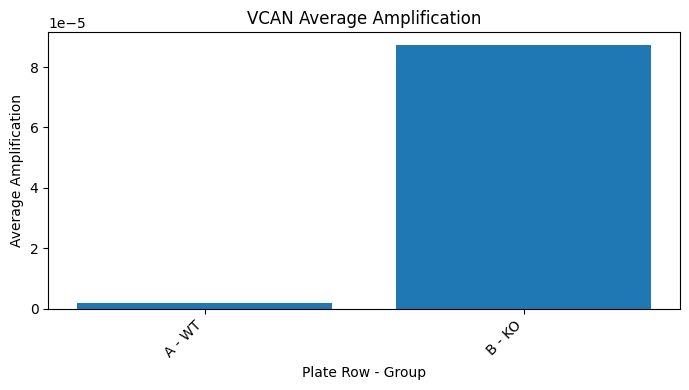

Saved graph: VCAN_average_amplification_bar_graph.png


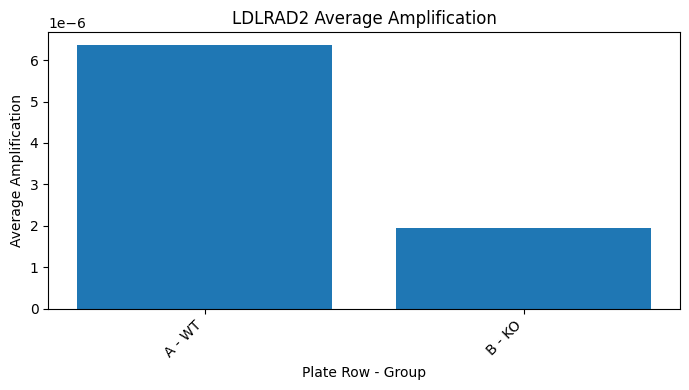

Saved graph: LDLRAD2_average_amplification_bar_graph.png


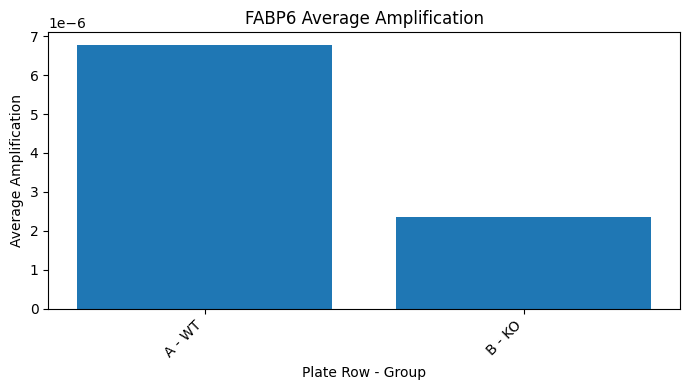

Saved graph: FABP6_average_amplification_bar_graph.png


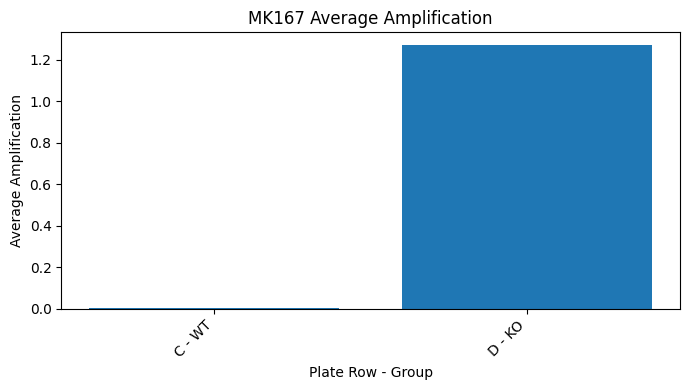

Saved graph: MK167_average_amplification_bar_graph.png


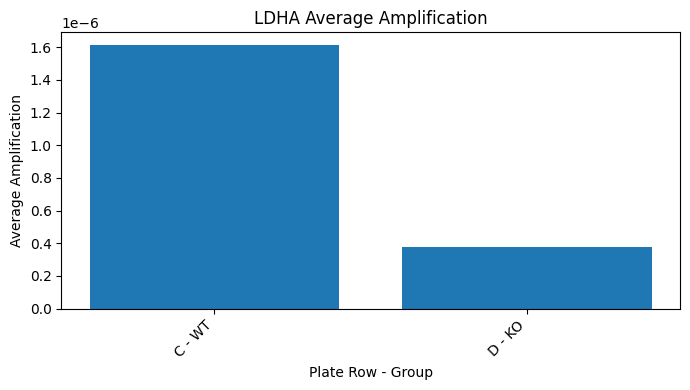

Saved graph: LDHA_average_amplification_bar_graph.png


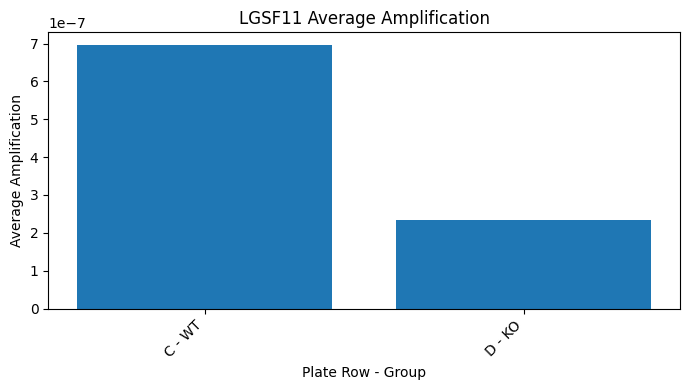

Saved graph: LGSF11_average_amplification_bar_graph.png


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Create one graph for each target primer
# ============================================================

for primer in final_summary_df.columns:

    # Skip blank primer names
    if pd.isna(primer) or str(primer).strip() == "":
        continue

    # Keep only nonmissing values for this primer
    graph_df = (
        final_summary_df[[primer]]
        .dropna()
    )

    # Skip columns with no values
    if graph_df.empty:
        continue

    # Create graph
    plt.figure(
        figsize=(7, 4)
    )

    plt.bar(
        graph_df.index,
        graph_df[primer]
    )

    plt.title(
        f"{primer} Average Amplification"
    )

    # The x-axis uses Row Sample so duplicate group names
    # from different plate rows remain separate bars.
    plt.xlabel(
        "Plate Row - Group"
    )

    plt.ylabel(
        "Average Amplification"
    )

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.tight_layout()


    # Create a filename without invalid characters
    safe_primer_name = (
        str(primer)
        .replace("/", "_")
        .replace("\\", "_")
        .replace(" ", "_")
    )

    graph_file = (
        f"{safe_primer_name}_"
        "average_amplification_bar_graph.png"
    )


    # Save graph
    plt.savefig(
        graph_file,
        dpi=300,
        bbox_inches="tight"
    )

    # Display graph
    plt.show()

    # Close graph to prevent figures from accumulating
    plt.close()

    print(
        f"Saved graph: {graph_file}"
    )
